In [41]:
# Imports 
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision
import mediapipe as mp
from mediapipe.tasks import python
import matplotlib.pyplot as plt
import pandas as pd 
import pickle as pkl
from tqdm import tqdm
import os 
from PIL import Image
import cv2

In [42]:
PATH = "C:/Users/leahz/Documents/ATC/pose-project/data"
input = f"{PATH}/099920730.jpg"

In [43]:
features = {
    "head" : [(8,7), (10,9), (8,10), (7,9)],
    "torso" : [(12,11), (24,23), (12,24), (11,23)],
    "left-leg": [(24,26), (26,28)],
    "right-leg": [(23,25), (25,27)],
    "legs":[(24,23), (26,25), (28,27), (30,32), (29,31)],
    "left-arm": [(12,14), (14,16)], 
    "right-arm": [(11,13), (13,15)],
    "full-body":[(0,24), (0,23), (0,12), (0,11)]
}

In [44]:
def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

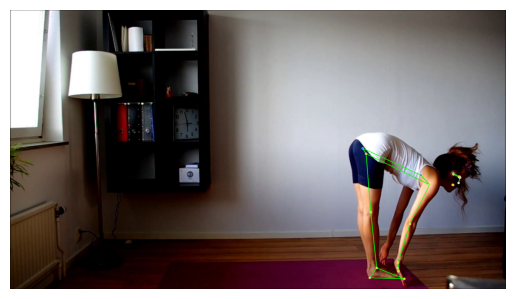

In [45]:
# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path=f'{PATH}/pose_landmarker_full.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)


# STEP 3: Load the input image.
image = mp.Image.create_from_file(f"{PATH}/mpii_human_pose_v1/images/000004812.jpg")

# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)


# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)


plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [46]:
detection_result

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.9046381711959839, y=0.6201422214508057, z=-0.005785902962088585, visibility=0.9993300437927246, presence=0.9995297193527222, name=None), NormalizedLandmark(x=0.9076353311538696, y=0.600636899471283, z=0.004217137582600117, visibility=0.999349057674408, presence=0.9993002414703369, name=None), NormalizedLandmark(x=0.9068396091461182, y=0.5989688634872437, z=0.004229059908539057, visibility=0.9995766282081604, presence=0.9993000030517578, name=None), NormalizedLandmark(x=0.9060538411140442, y=0.5971686840057373, z=0.0041836900636553764, visibility=0.9996262788772583, presence=0.9992290735244751, name=None), NormalizedLandmark(x=0.9071896076202393, y=0.6010573506355286, z=-0.023528052493929863, visibility=0.9994422793388367, presence=0.999200165271759, name=None), NormalizedLandmark(x=0.90608149766922, y=0.5998131036758423, z=-0.023604508489370346, visibility=0.9994864463806152, presence=0.9990864992141724, name=None), Normalize

# Skeleton Sketch

In [93]:
class Skeleton:
    def __init__(self, joints, edges, joint_meta=None, edge_meta=None):
        self.joints = joints.astype(float)              # (N,2)
        self.edges = edges.astype(int)                  # (E,2)

        self.joint_meta = joint_meta if joint_meta else [{} for _ in range(len(joints))]
        self.edge_meta = edge_meta if edge_meta else [{} for _ in range(len(edges))]

    # geometric transformations

    def jitter_joints(self, sigma=0.01):
        noise = np.random.normal(0, sigma, self.joints.shape)
        self.joints += noise

    def move_joint(self, i, dx, dy):
        self.joints[i] += np.array([dx, dy])

    def scale(self, factor):
        self.joints *= factor

    def translate(self, dx, dy):
        self.joints += np.array([dx, dy])

    # structural modifications

    def drop_edge(self, idx):
        self.edge_meta[idx]["visible"] = False

    def drop_edges_by_type(self, edge_type):
        for i, meta in enumerate(self.edge_meta):
            if meta.get("type") == edge_type:
                meta["visible"] = False

    def drop_joint(self, idx):
        self.joint_meta[idx]["visible"] = False

    # rendering
    def render(self, size=300):
        canvas = np.ones((size, size), dtype=np.uint8) * 255

        # Draw edges
        for (i, (a, b)) in enumerate(self.edges):
            meta = self.edge_meta[i]
            if meta.get("visible", True) is False:
                continue

            p1 = tuple((self.joints[a][:2] * size).astype(int))
            p2 = tuple((self.joints[b][:2] * size).astype(int))

            thickness = meta.get("thickness", 2)
            cv2.line(canvas, p1, p2, color=0, thickness=thickness)

        # Draw joints
        for i, joint in enumerate(self.joints):
            meta = self.joint_meta[i]
            if meta.get("visible", True) is False:
                continue

            center = tuple((joint[:2] * size).astype(int))
            radius = meta.get("radius", 2)

            cv2.circle(canvas, center, radius, color=0, thickness=-1)

        return canvas

In [94]:
# joints is all the landmarks 
# edges are the tuples of indices into the joints array that define the skeleton structure that I choose
edges = [
    # head 
    (8,6),(6,5),(5,4),(4,0),(0,1),(1,2),(2,3),(3,7),(10,9),
    # torso
    (12,11), (24,23), (12,24), (11,23),
    # left-leg
    (24,26), (26,28),
    # right-leg
    (23,25), (25,27),
    # left-arm
    (12,14), (14,16),
    # right-arm
    (11,13), (13,15),
    # left foot
    (28,30), (30,32), (32,28),
    # right foot
    (27,29), (29,31), (31,27),
    # left hand
    (16,18), (18,20), (20,16), (16,22),
    # right hand
    (15,17), (17,19), (19,15), (15,21)
]

JOINT_CATEGORIES = {
    "head": [0,1,2,3,4,5,6,7,8,9,10],
    "torso": [11,12,23,24],
    "left_arm": [11,13,15],
    "right_arm": [12,14,16],
    "left_leg": [23,25,27],
    "right_leg": [24,26,28],
    "left_hand": [15,17,18,19,20,22],
    "right_hand": [16,18,19,20,21],
    "left_foot": [28,30,32],
    "right_foot": [27,29,31]
}




In [95]:
detection_result.pose_world_landmarks[0]

[Landmark(x=0.6090859174728394, y=0.263674795627594, z=-0.012665720656514168, visibility=0.9993300437927246, presence=0.9995297193527222, name=None),
 Landmark(x=0.6290792226791382, y=0.22555696964263916, z=-0.00633199280127883, visibility=0.999349057674408, presence=0.9993002414703369, name=None),
 Landmark(x=0.6292476654052734, y=0.22611016035079956, z=-0.005539468955248594, visibility=0.9995766282081604, presence=0.9993000030517578, name=None),
 Landmark(x=0.6297169327735901, y=0.2259865403175354, z=-0.005637429188936949, visibility=0.9996262788772583, presence=0.9992290735244751, name=None),
 Landmark(x=0.62435382604599, y=0.22564661502838135, z=-0.03436931222677231, visibility=0.9994422793388367, presence=0.999200165271759, name=None),
 Landmark(x=0.6249830722808838, y=0.22643287479877472, z=-0.03523759916424751, visibility=0.9994864463806152, presence=0.9990864992141724, name=None),
 Landmark(x=0.6264437437057495, y=0.22626642882823944, z=-0.03444526717066765, visibility=0.999429

In [96]:
def construct_skeleton_from_mediapipe_result(detection_result, edges, image_size=None):
    """
    Constructs a Skeleton from a MediaPipe detection result.
    
    Args:
        detection_result: MediaPipe pose detection result.
        edges: list of (start, end) tuples defining the skeleton connectivity.
        image_size: (width, height) to scale normalized coordinates  to pixel space.
                    If None, keeps normalized coordinates [0,1].
    
    Returns:
        Skeleton instance with joints, edges, joint_meta, and edge_meta.
    """
    joints = []
    joint_meta = []
    
    for i, landmark in enumerate(detection_result.pose_world_landmarks[0]):    
            # scale to pixel coordinates if image_size is provided
            if image_size is not None:
                x = landmark.x * image_size[0]
                y = landmark.y * image_size[1]
                z = landmark.z  # keep z as-is
            else:
                x, y, z = landmark.x, landmark.y, landmark.z
            
            # assign category based on JOINT_CATEGORIES mapping
            category = None
            for cat, indices in JOINT_CATEGORIES.items():
                if i in indices:
                    category = cat
                    break
            
            joints.append([x, y, z])
            joint_meta.append({
                "category": category,
                "visibility": landmark.visibility,
            })
    
    joints = np.array(joints, dtype=float)
    
    # build edge_meta with visibility info
    edge_meta = []
    for (a, b) in edges:
        visible = True
        if joint_meta[a]["visibility"] < 0.5 or joint_meta[b]["visibility"] < 0.5:
            visible = False
        edge_meta.append({
            "start": a,
            "end": b,
            "visible": visible,
            "thickness": 2,
            "type": None  # optionally assign type based on joint categories
        })
    
    return Skeleton(joints=joints, edges=np.array(edges, dtype=int),
                    joint_meta=joint_meta, edge_meta=edge_meta)

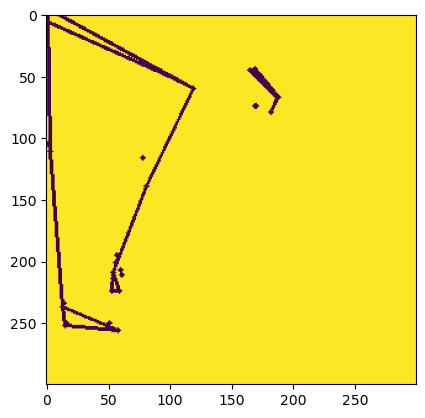

In [99]:
skeleton = construct_skeleton_from_mediapipe_result(detection_result, edges)
plt.imshow(skeleton.render())

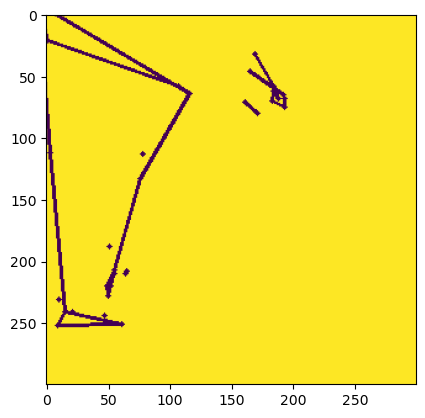

In [100]:
skeleton.jitter_joints(sigma=0.02)
plt.imshow(skeleton.render())

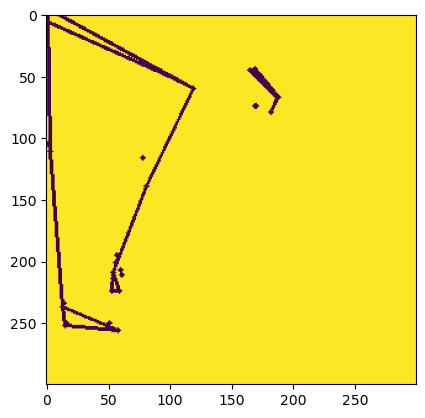

In [ ]:
def compose_sketch_from_skeleton(skeleton, edge_types_to_emphasize=None):
    """
    Composes a sketch image from the given skeleton, emphasizing specified edge types.
    
    Args:
        skeleton: Skeleton instance containing joints, edges, and metadata.
        edge_types_to_emphasize: list of edge types to render with increased thickness.
        """